In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

telco = pd.read_csv("telco_customer_churn.csv")

#basic dataset structure
print(telco.shape)
telco.head() 

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
 

(7043, 21)


In [13]:
#cleaning TotalCharges
telco['TotalCharges'] = telco['TotalCharges'].replace(" ", np.nan)
telco['TotalCharges'] = pd.to_numeric(telco['TotalCharges'], errors='coerce')
telco['TotalCharges'].fillna(telco['TotalCharges'].median(), inplace=True)

#droping duplicates
telco.drop_duplicates(inplace=True)

#confirming that data exists
print("Rows after cleaning:", len(telco))
print(telco['Churn'].value_counts()) 

Rows after cleaning: 7043
Churn
No     5174
Yes    1869
Name: count, dtype: int64


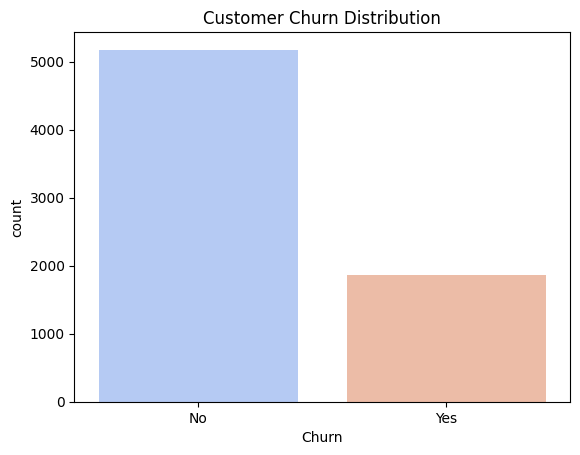

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [14]:
#churn distribution EDA
sns.countplot(x='Churn', data=telco, palette='coolwarm')
plt.title("Customer Churn Distribution")
plt.show()

print(telco['Churn'].value_counts(normalize=True) * 100)


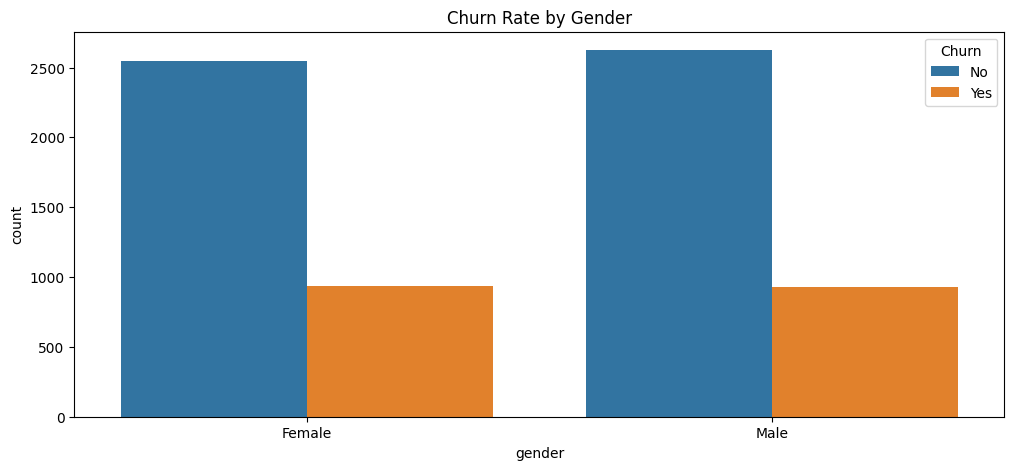

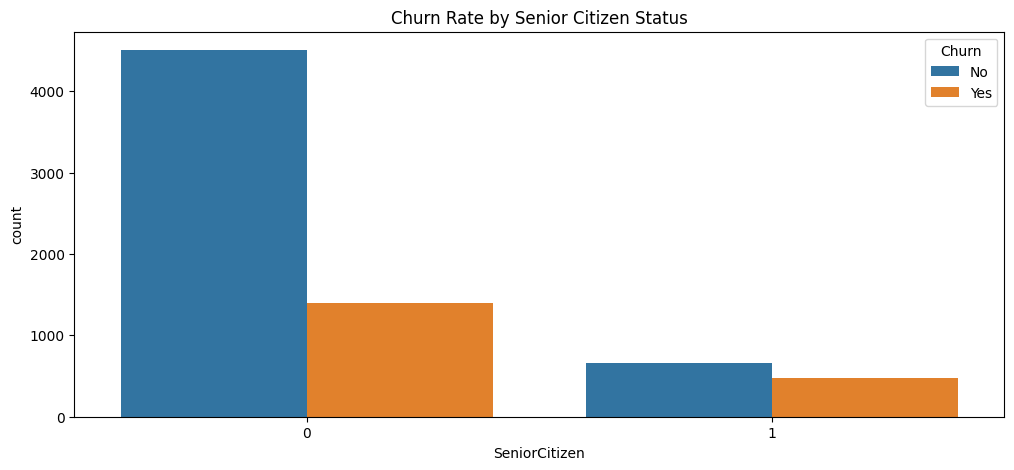

In [15]:
#demographic insights
plt.figure(figsize=(12,5))
sns.countplot(x='gender', hue='Churn', data=telco)
plt.title("Churn Rate by Gender")
plt.show()

plt.figure(figsize=(12,5))
sns.countplot(x='SeniorCitizen', hue='Churn', data=telco)
plt.title("Churn Rate by Senior Citizen Status")
plt.show() 

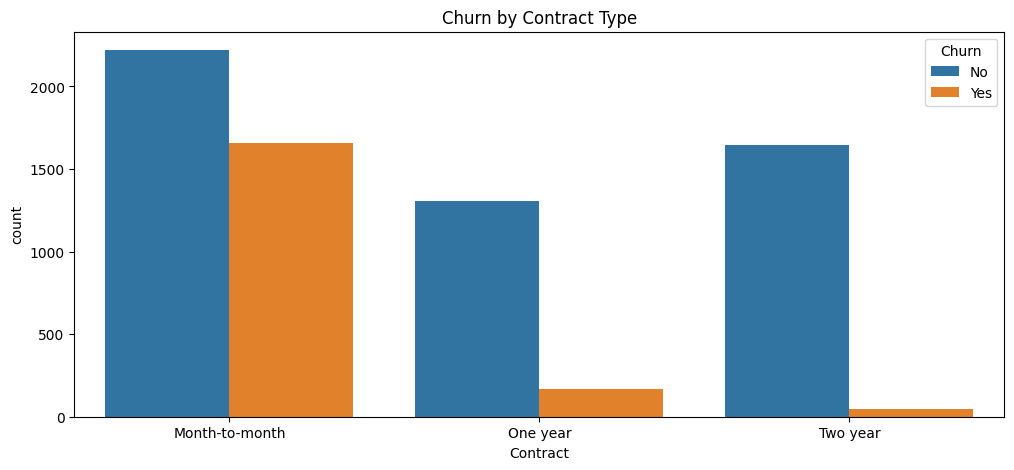

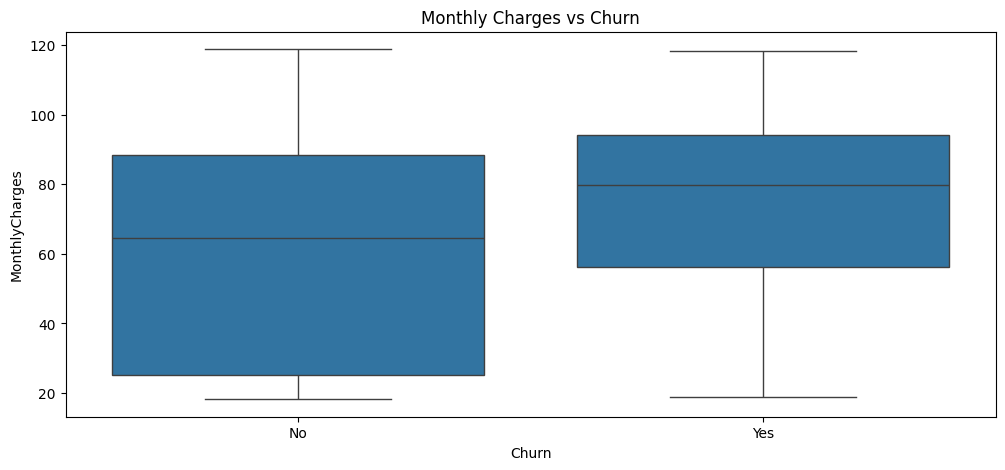

In [16]:
#service and contract insights
plt.figure(figsize=(12,5))
sns.countplot(x='Contract', hue='Churn', data=telco)
plt.title("Churn by Contract Type")
plt.show()

plt.figure(figsize=(12,5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=telco)
plt.title("Monthly Charges vs Churn")
plt.show() 

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

#always reload this cell to start fresh (lmao, because 'Churn' is numeric. mapping it again converts 1.0/0.0 to NaN)
telco = pd.read_csv("telco_customer_churn.csv")

#cleaning TotalCharges
telco['TotalCharges'] = telco['TotalCharges'].replace(" ", np.nan)
telco['TotalCharges'] = pd.to_numeric(telco['TotalCharges'], errors='coerce')
telco['TotalCharges'].fillna(telco['TotalCharges'].median(), inplace=True)
telco.drop_duplicates(inplace=True)

#making a copy of the df to protect the original
telco_copy = telco.copy()

#encoding target
telco_copy['Churn'] = telco_copy['Churn'].map({'Yes': 1, 'No': 0})
telco_copy = telco_copy.dropna(subset=['Churn'])

#encoding categorical variables
cat_cols = telco_copy.select_dtypes(include=['object']).columns.tolist()
cat_cols = [c for c in cat_cols if c != 'customerID']

encoder = LabelEncoder()
for col in cat_cols:
    telco_copy[col] = encoder.fit_transform(telco_copy[col])

#splitting features & target
X = telco_copy.drop(['Churn', 'customerID'], axis=1)
y = telco_copy['Churn']

#training-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Stable split complete!")
print(f"Rows: {telco_copy.shape[0]}, Features: {X.shape[1]}")
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}") 


Stable split complete!
Rows: 7043, Features: 19
Train: 5634, Test: 1409



Logistic Regression Model Evaluation
Accuracy: 0.7999
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409


Random Forest Model Evaluation
Accuracy: 0.8006
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



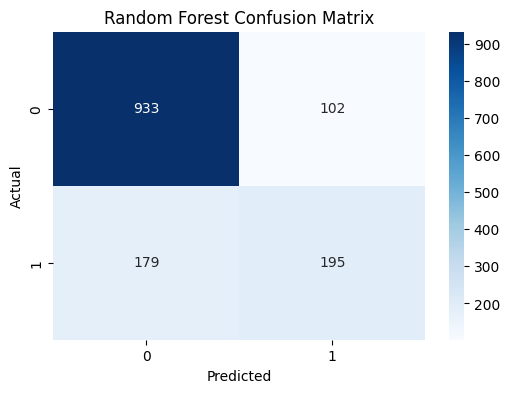

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt 

#logistic regression
log_model = LogisticRegression(max_iter=5000, random_state=42)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

#random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=200, 
    max_depth=10, 
    random_state=42
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

#evaluation Function
def evaluate_model(name, y_true, y_pred):
    print(f"\n{name} Model Evaluation")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print("Classification Report:")
    print(classification_report(y_true, y_pred))

#evaluating both models
evaluate_model("Logistic Regression", y_test, y_pred_log)
evaluate_model("Random Forest", y_test, y_pred_rf)

#confusion Matrix (Random Forest)
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [21]:
#getting feature importance from logistic regression coefficients
feature_importance_log = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': log_model.coef_[0]
})

#sortting by absolute importance
feature_importance_log['AbsCoefficient'] = feature_importance_log['Coefficient'].abs()
feature_importance_log = feature_importance_log.sort_values(by='AbsCoefficient', ascending=False)

#displaying top 10 features
print("Top 10 Logistic Regression Feature Effects on Churn:")
display(feature_importance_log.head(10))


Top 10 Logistic Regression Feature Effects on Churn:


,Feature,Coefficient,AbsCoefficient
5,PhoneService,-0.960919,0.960919
14,Contract,-0.721948,0.721948
15,PaperlessBilling,0.395670,0.395670
8,OnlineSecurity,-0.286510,0.286510
11,TechSupport,-0.264929,0.264929
7,InternetService,0.235107,0.235107
3,Dependents,-0.234395,0.234395
1,SeniorCitizen,0.171891,0.171891
9,OnlineBackup,-0.149903,0.149903
6,MultipleLines,0.091961,0.091961


In [20]:
import plotly.express as px 

#getting feature importances from Random Forest
rf_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

#interactive Plotly bar chart
fig = px.bar(
    rf_importances.head(15),
    x='Importance',
    y='Feature',
    orientation='h',
    title='Top 15 Features Driving Customer Churn (Random Forest)',
    text='Importance'
)
fig.update_traces(texttemplate='%{text:.3f}', textposition='outside')
fig.update_layout(yaxis={'categoryorder': 'total ascending'}, height=600)
fig.show()
